# Phase 2 Spark-to-Ray Forecasting Visualizations

This notebook visualizes saved Phase 2 outputs from the Spark-to-Ray forecasting workflow. It uses only files already present in `phase2/data/derived/` and does not rebuild features, rerun Ray models, or retrain the Ray Train MLP.


## 1. Setup and Artifact Inventory

The first cells define repo-relative paths, inspect the derived-output directory, and report which artifacts are available. The feature table is required for dataset context; other artifacts are optional and their plots are skipped if missing.


In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 120)
plt.style.use("default")

start_dir = Path.cwd().resolve()
repo_root = None
for candidate in [start_dir, *start_dir.parents]:
    if (candidate / "phase2" / "data" / "derived").exists():
        repo_root = candidate
        break

if repo_root is None:
    raise FileNotFoundError("Could not find repo root containing phase2/data/derived.")

derived_dir = repo_root / "phase2" / "data" / "derived"

print("Repo root:", repo_root)
print("Derived output directory:", derived_dir)
print("Derived directory exists:", derived_dir.exists())


Repo root: C:\Users\nolan\OneDrive\Desktop\Code\CS8540 Project\CS8540-Project
Derived output directory: C:\Users\nolan\OneDrive\Desktop\Code\CS8540 Project\CS8540-Project\phase2\data\derived
Derived directory exists: True


In [2]:
important_files = {
    "feature_table": "top_tags_daily_features.parquet",
    "baseline_predictions": "baseline_forecast_predictions_count_only.parquet",
    "baseline_metrics_overall": "baseline_forecast_metrics_overall_count_only.csv",
    "baseline_metrics_by_tag": "baseline_forecast_metrics_by_tag_count_only.csv",
    "baseline_metrics_by_tag_type": "baseline_forecast_metrics_by_tag_type_count_only.csv",
    "ray_predictions": "ray_model_predictions_count_only.parquet",
    "ray_metrics_overall": "ray_model_metrics_overall_count_only.csv",
    "ray_metrics_by_tag": "ray_model_metrics_by_tag_count_only.csv",
    "ray_metrics_by_tag_type": "ray_model_metrics_by_tag_type_count_only.csv",
    "ray_training_times": "ray_model_training_times_count_only.csv",
    "ray_run_summary": "ray_model_run_summary_count_only.json",
    "mlp_predictions": "ray_train_mlp_predictions_mlp_count_only.parquet",
    "mlp_metrics": "ray_train_mlp_metrics_mlp_count_only.csv",
    "mlp_metrics_by_tag": "ray_train_mlp_metrics_by_tag_mlp_count_only.csv",
    "mlp_metrics_by_tag_type": "ray_train_mlp_metrics_by_tag_type_mlp_count_only.csv",
    "mlp_history": "ray_train_mlp_training_history_mlp_count_only.csv",
    "mlp_training_time": "ray_train_mlp_training_time_mlp_count_only.csv",
    "mlp_run_summary": "ray_train_mlp_run_summary_mlp_count_only.json",
    "sentiment_comparison": "sentiment_forecast_comparison.csv",
    "sentiment_feature_table": "top_tags_daily_features_with_sentiment.parquet",
}

inventory_rows = []
for name, filename in important_files.items():
    path = derived_dir / filename
    inventory_rows.append({
        "artifact": name,
        "path": str(path),
        "exists": path.exists(),
        "size_kb": round(path.stat().st_size / 1024, 1) if path.exists() else np.nan,
    })

inventory = pd.DataFrame(inventory_rows)
display(inventory)

print("Artifacts found:")
for _, row in inventory[inventory["exists"]].iterrows():
    print(" -", row["artifact"], "->", row["path"])

missing = inventory[~inventory["exists"]]
if not missing.empty:
    print("\nArtifacts missing or skipped if needed:")
    for _, row in missing.iterrows():
        print(" -", row["artifact"], "->", row["path"])


,artifact,path,exists,size_kb
0,feature_table,C:\Users\nolan\OneDrive\Desktop\Code\CS8540 Pr...,True,194.4
1,baseline_predictions,C:\Users\nolan\OneDrive\Desktop\Code\CS8540 Pr...,True,47.6
2,baseline_metrics_overall,C:\Users\nolan\OneDrive\Desktop\Code\CS8540 Pr...,True,0.7
3,baseline_metrics_by_tag,C:\Users\nolan\OneDrive\Desktop\Code\CS8540 Pr...,True,2.4
4,baseline_metrics_by_tag_type,C:\Users\nolan\OneDrive\Desktop\Code\CS8540 Pr...,True,1.6
5,ray_predictions,C:\Users\nolan\OneDrive\Desktop\Code\CS8540 Pr...,True,38.1
6,ray_metrics_overall,C:\Users\nolan\OneDrive\Desktop\Code\CS8540 Pr...,True,0.9
7,ray_metrics_by_tag,C:\Users\nolan\OneDrive\Desktop\Code\CS8540 Pr...,True,2.9
8,ray_metrics_by_tag_type,C:\Users\nolan\OneDrive\Desktop\Code\CS8540 Pr...,True,2.0
9,ray_training_times,C:\Users\nolan\OneDrive\Desktop\Code\CS8540 Pr...,True,0.4


Artifacts found:
 - feature_table -> C:\Users\nolan\OneDrive\Desktop\Code\CS8540 Project\CS8540-Project\phase2\data\derived\top_tags_daily_features.parquet
 - baseline_predictions -> C:\Users\nolan\OneDrive\Desktop\Code\CS8540 Project\CS8540-Project\phase2\data\derived\baseline_forecast_predictions_count_only.parquet
 - baseline_metrics_overall -> C:\Users\nolan\OneDrive\Desktop\Code\CS8540 Project\CS8540-Project\phase2\data\derived\baseline_forecast_metrics_overall_count_only.csv
 - baseline_metrics_by_tag -> C:\Users\nolan\OneDrive\Desktop\Code\CS8540 Project\CS8540-Project\phase2\data\derived\baseline_forecast_metrics_by_tag_count_only.csv
 - baseline_metrics_by_tag_type -> C:\Users\nolan\OneDrive\Desktop\Code\CS8540 Project\CS8540-Project\phase2\data\derived\baseline_forecast_metrics_by_tag_type_count_only.csv
 - ray_predictions -> C:\Users\nolan\OneDrive\Desktop\Code\CS8540 Project\CS8540-Project\phase2\data\derived\ray_model_predictions_count_only.parquet
 - ray_metrics_overall -

In [3]:
def read_csv_if_exists(filename):
    path = derived_dir / filename
    return pd.read_csv(path) if path.exists() else None


def read_parquet_if_exists(filename):
    path = derived_dir / filename
    return pd.read_parquet(path) if path.exists() else None


def read_json_if_exists(filename):
    path = derived_dir / filename
    if not path.exists():
        return None
    with open(path, "r", encoding="utf-8") as handle:
        return json.load(handle)


def note(message):
    print("NOTE:", message)

feature_path = derived_dir / important_files["feature_table"]
if not feature_path.exists():
    raise FileNotFoundError(
        "Missing required feature table: phase2/data/derived/top_tags_daily_features.parquet. "
        "This notebook uses saved derived outputs only, so run it after that artifact exists."
    )


## 2. Dataset and Feature-Table Overview

The feature table is the modeling dataset created from Spark daily hashtag and cashtag count outputs. These plots describe the selected forecasting panel before model evaluation.


In [4]:
features = pd.read_parquet(feature_path)
features["date"] = pd.to_datetime(features["date"])

print("Feature table shape:", features.shape)
print("Date range:", features["date"].min().date(), "to", features["date"].max().date())
print("Selected tags by type:")
display(features[["tag_type", "tag"]].drop_duplicates().groupby("tag_type").size().rename("tags").reset_index())

display(features.head())


Feature table shape: (2310, 23)
Date range: 2020-04-09 to 2020-07-16
Selected tags by type:


,tag_type,tags
0,cashtag,15
1,hashtag,15


,date,tag,tag_type,count,target_next_count,count_lag_1,count_lag_2,count_lag_3,count_lag_7,rolling_mean_3,rolling_std_3,rolling_mean_7,rolling_std_7,count_diff_1,count_pct_change_1,day_of_week,day_index,anomaly_trailing_mean_7,anomaly_trailing_std_7,anomaly_deviation_7,anomaly_z_ready_7,split,modeling_ready
0,2020-04-09,$AAPL,cashtag,677,303.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,0,NaN,NaN,NaN,NaN,train,False
1,2020-04-10,$AAPL,cashtag,303,198.0,677.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-374.0,-0.552437,4,1,NaN,NaN,NaN,NaN,train,False
2,2020-04-11,$AAPL,cashtag,198,193.0,303.0,677.0,NaN,NaN,392.666667,251.774370,NaN,NaN,-105.0,-0.346535,5,2,NaN,NaN,NaN,NaN,train,False
3,2020-04-12,$AAPL,cashtag,193,669.0,198.0,303.0,677.0,NaN,231.333333,62.115484,NaN,NaN,-5.0,-0.025253,6,3,NaN,NaN,NaN,NaN,train,False
4,2020-04-13,$AAPL,cashtag,669,1000.0,193.0,198.0,303.0,NaN,353.333333,273.386783,NaN,NaN,476.0,2.466321,0,4,NaN,NaN,NaN,NaN,train,False


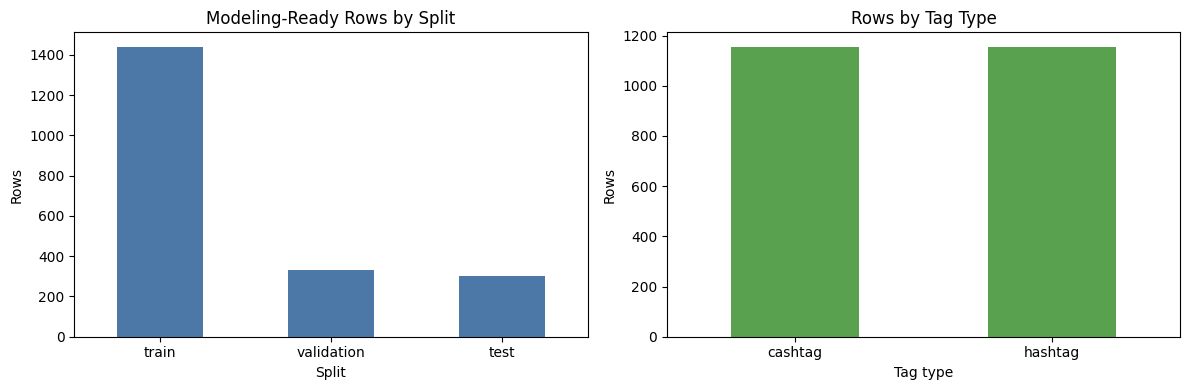

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

split_counts = features.loc[features["modeling_ready"], "split"].value_counts().reindex(["train", "validation", "test"])
split_counts.plot(kind="bar", ax=axes[0], color="#4C78A8")
axes[0].set_title("Modeling-Ready Rows by Split")
axes[0].set_xlabel("Split")
axes[0].set_ylabel("Rows")
axes[0].tick_params(axis="x", rotation=0)

features["tag_type"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#59A14F")
axes[1].set_title("Rows by Tag Type")
axes[1].set_xlabel("Tag type")
axes[1].set_ylabel("Rows")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


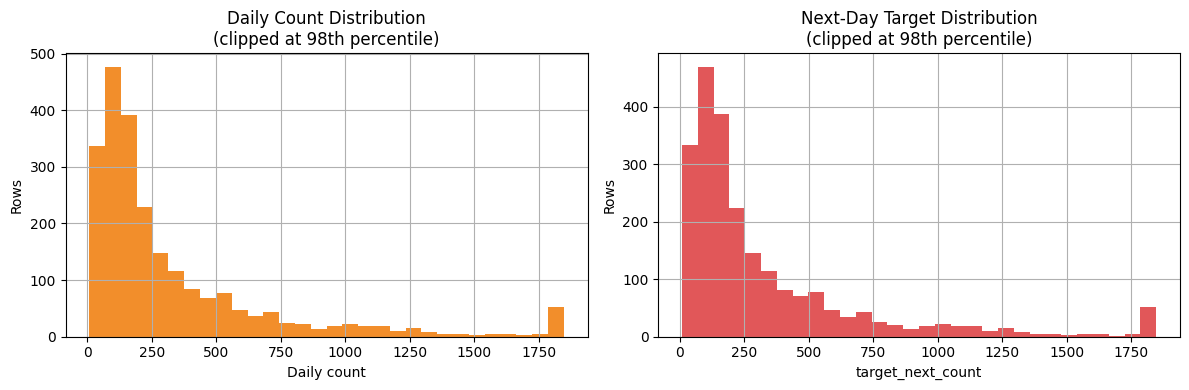

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

features["count"].clip(upper=features["count"].quantile(0.98)).hist(bins=30, ax=axes[0], color="#F28E2B")
axes[0].set_title("Daily Count Distribution\n(clipped at 98th percentile)")
axes[0].set_xlabel("Daily count")
axes[0].set_ylabel("Rows")

features["target_next_count"].dropna().clip(upper=features["target_next_count"].quantile(0.98)).hist(
    bins=30, ax=axes[1], color="#E15759"
)
axes[1].set_title("Next-Day Target Distribution\n(clipped at 98th percentile)")
axes[1].set_xlabel("target_next_count")
axes[1].set_ylabel("Rows")

plt.tight_layout()
plt.show()


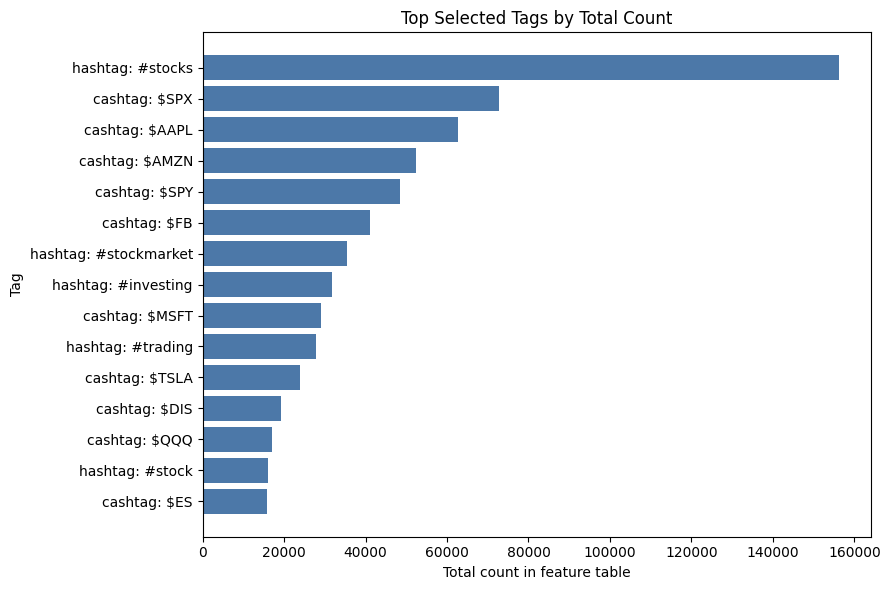

,tag_type,tag,count
28,hashtag,#stocks,156189
12,cashtag,$SPX,72808
0,cashtag,$AAPL,62580
1,cashtag,$AMZN,52357
13,cashtag,$SPY,48459
5,cashtag,$FB,41047
27,hashtag,#stockmarket,35414
20,hashtag,#investing,31843
9,cashtag,$MSFT,29082
29,hashtag,#trading,27850


In [7]:
tag_volume = (
    features.groupby(["tag_type", "tag"], as_index=False)["count"]
    .sum()
    .sort_values("count", ascending=False)
)

top_volume = tag_volume.head(15).sort_values("count")
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_volume["tag_type"] + ": " + top_volume["tag"], top_volume["count"], color="#4C78A8")
ax.set_title("Top Selected Tags by Total Count")
ax.set_xlabel("Total count in feature table")
ax.set_ylabel("Tag")
plt.tight_layout()
plt.show()

display(tag_volume.head(10))


## 3. Overall Model Performance Comparison

This section combines available baseline, classical Ray, and Ray Train MLP metric files. The main report metric is sMAPE, with MAE and RMSE kept in the tables.


In [8]:
baseline_metrics = read_csv_if_exists("baseline_forecast_metrics_overall_count_only.csv")
ray_metrics = read_csv_if_exists("ray_model_metrics_overall_count_only.csv")
mlp_metrics = read_csv_if_exists("ray_train_mlp_metrics_mlp_count_only.csv")

metric_frames = []
if baseline_metrics is not None:
    temp = baseline_metrics.copy()
    if "baseline" in temp.columns and "model" not in temp.columns:
        temp = temp.rename(columns={"baseline": "model"})
    temp["source"] = "baseline"
    metric_frames.append(temp)
else:
    note("Baseline overall metrics are missing.")

if ray_metrics is not None:
    temp = ray_metrics.copy()
    temp["source"] = "classical_ray"
    metric_frames.append(temp)
else:
    note("Classical Ray overall metrics are missing.")

if mlp_metrics is not None:
    temp = mlp_metrics.copy()
    temp["source"] = "ray_train_mlp"
    metric_frames.append(temp)
else:
    note("Ray Train MLP overall metrics are missing.")

all_metrics = pd.concat(metric_frames, ignore_index=True) if metric_frames else pd.DataFrame()
if not all_metrics.empty:
    all_metrics["model"] = all_metrics["model"].fillna("unknown").astype(str)
    display(all_metrics.sort_values(["split", "sMAPE", "MAE"]))
else:
    note("No model metrics are available for comparison.")


,split,model,rows,MAE,RMSE,sMAPE,source
13,test,random_forest_pooled,300,106.683195,190.429559,24.780038,classical_ray
15,test,hist_gradient_boosting_pooled,300,107.291603,180.732363,25.658922,classical_ray
19,test,ray_train_mlp,300,104.442398,182.176636,25.733625,ray_train_mlp
11,test,ridge_regression_pooled,300,117.163668,207.928685,27.448188,classical_ray
9,test,linear_regression_pooled,300,120.785369,208.132004,29.222381,classical_ray
0,test,baseline_last_value,300,132.200000,260.080039,30.433236,baseline
16,test,baseline_last_value,300,132.200000,260.080039,30.433236,classical_ray
2,test,baseline_rolling_mean_7,300,149.954762,255.163483,35.359173,baseline
1,test,baseline_lag_7,300,139.733333,284.247932,36.738714,baseline
3,test,baseline_rolling_mean_3,300,173.161111,294.530759,41.100795,baseline


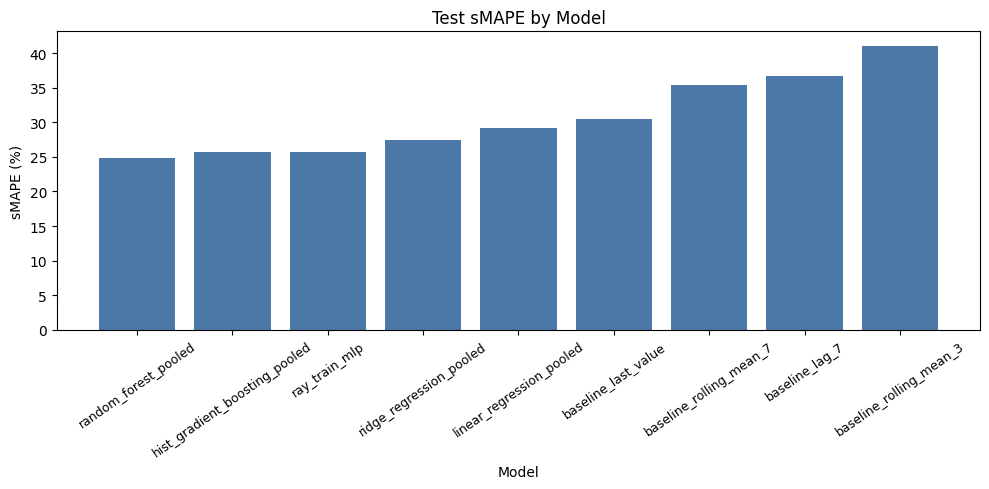

In [9]:
if not all_metrics.empty and "test" in set(all_metrics["split"]):
    test_metrics = all_metrics[all_metrics["split"].eq("test")].copy().sort_values("sMAPE")
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(test_metrics["model"], test_metrics["sMAPE"], color="#4C78A8")
    ax.set_title("Test sMAPE by Model")
    ax.set_xlabel("Model")
    ax.set_ylabel("sMAPE (%)")
    ax.tick_params(axis="x", rotation=35, labelsize=9)
    plt.tight_layout()
    plt.show()
else:
    note("Skipping test sMAPE bar chart because test metrics are unavailable.")


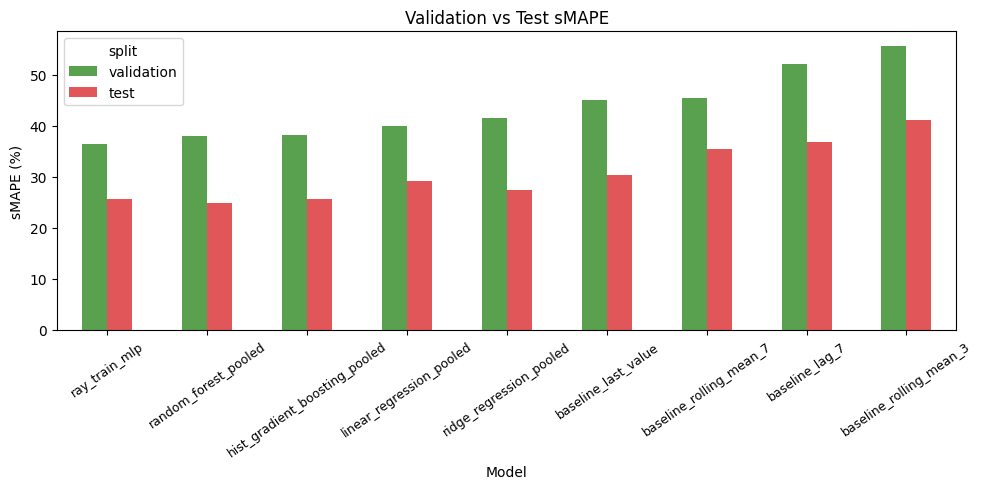

In [10]:
if not all_metrics.empty:
    plot_data = all_metrics[all_metrics["split"].isin(["validation", "test"])].copy()
    if not plot_data.empty:
        pivot = plot_data.pivot_table(index="model", columns="split", values="sMAPE", aggfunc="first")
        pivot = pivot[[col for col in ["validation", "test"] if col in pivot.columns]].sort_values(pivot.columns[-1])
        ax = pivot.plot(kind="bar", figsize=(10, 5), color=["#59A14F", "#E15759"][: len(pivot.columns)])
        ax.set_title("Validation vs Test sMAPE")
        ax.set_xlabel("Model")
        ax.set_ylabel("sMAPE (%)")
        ax.tick_params(axis="x", rotation=35, labelsize=9)
        plt.tight_layout()
        plt.show()
else:
    note("Skipping validation/test comparison because metrics are unavailable.")


## 4. Best-Model Comparison

The classical Ray winner is selected by validation sMAPE. The MLP is then compared honestly against that model on validation and test metrics.


In [11]:
best_classical = None
mlp_row_validation = None
mlp_row_test = None

if ray_metrics is not None and not ray_metrics.empty:
    validation_ray = ray_metrics[ray_metrics["split"].eq("validation")].copy()
    if not validation_ray.empty:
        best_classical_name = validation_ray.sort_values(["sMAPE", "MAE"]).iloc[0]["model"]
        best_classical = ray_metrics[ray_metrics["model"].eq(best_classical_name)].copy()
        print("Best classical Ray model by validation sMAPE:", best_classical_name)
        display(best_classical)
    else:
        note("Classical Ray validation metrics are missing.")
else:
    note("Classical Ray metrics are missing, so no classical winner can be selected.")

if mlp_metrics is not None and not mlp_metrics.empty:
    display(mlp_metrics)
    mlp_row_validation = mlp_metrics[mlp_metrics["split"].eq("validation")]
    mlp_row_test = mlp_metrics[mlp_metrics["split"].eq("test")]
else:
    note("MLP metrics are missing, so no MLP comparison can be shown.")

if best_classical is not None and mlp_metrics is not None and not mlp_metrics.empty:
    comparison = pd.concat([best_classical, mlp_metrics], ignore_index=True)
    display(comparison.sort_values(["split", "sMAPE"]))
    test_compare = comparison[comparison["split"].eq("test")].sort_values("sMAPE")
    if len(test_compare) >= 2:
        winner = test_compare.iloc[0]
        print(f"Best test sMAPE in this comparison: {winner['model']} ({winner['sMAPE']:.2f}%).")


Best classical Ray model by validation sMAPE: random_forest_pooled


,split,model,rows,MAE,RMSE,sMAPE
4,validation,random_forest_pooled,330,124.687109,228.405360,38.027573
5,test,random_forest_pooled,300,106.683195,190.429559,24.780038


,split,model,rows,MAE,RMSE,sMAPE
0,validation,ray_train_mlp,330,113.438006,209.733083,36.520149
1,test,ray_train_mlp,300,104.442398,182.176636,25.733625


,split,model,rows,MAE,RMSE,sMAPE
1,test,random_forest_pooled,300,106.683195,190.429559,24.780038
3,test,ray_train_mlp,300,104.442398,182.176636,25.733625
2,validation,ray_train_mlp,330,113.438006,209.733083,36.520149
0,validation,random_forest_pooled,330,124.687109,228.405360,38.027573


Best test sMAPE in this comparison: random_forest_pooled (24.78%).


## 5. Actual vs Predicted Examples

These plots compare observed next-day tag count to model predictions for one representative hashtag and one representative cashtag. Plots are skipped if prediction parquet files are unavailable.


In [12]:
ray_predictions = read_parquet_if_exists("ray_model_predictions_count_only.parquet")
mlp_predictions = read_parquet_if_exists("ray_train_mlp_predictions_mlp_count_only.parquet")

if ray_predictions is None:
    note("Classical Ray prediction parquet is missing.")
if mlp_predictions is None:
    note("MLP prediction parquet is missing.")

for frame in [ray_predictions, mlp_predictions]:
    if frame is not None and "date" in frame.columns:
        frame["date"] = pd.to_datetime(frame["date"])

candidate_source = mlp_predictions if mlp_predictions is not None else ray_predictions
representative_tags = []
if candidate_source is not None:
    for tag_type in ["hashtag", "cashtag"]:
        rows = candidate_source[candidate_source["tag_type"].eq(tag_type)]
        if not rows.empty:
            tag_counts = rows.groupby("tag")["target_next_count"].sum().sort_values(ascending=False)
            representative_tags.append((tag_type, tag_counts.index[0]))

print("Representative tags:", representative_tags)


Representative tags: [('hashtag', '#stocks'), ('cashtag', '$AAPL')]


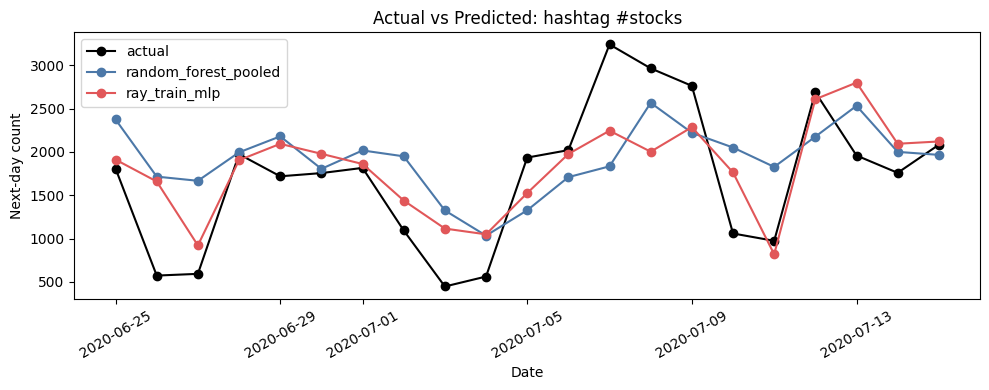

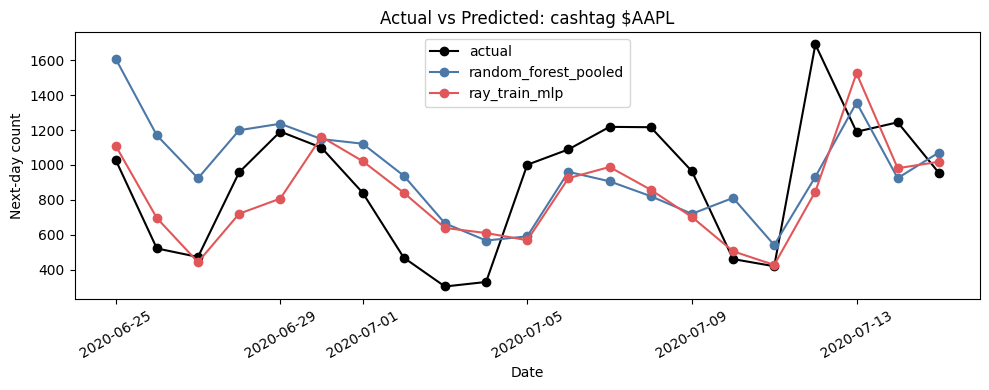

In [13]:
def plot_predictions_for_tag(tag_type, tag):
    fig, ax = plt.subplots(figsize=(10, 4))
    plotted = False

    if ray_predictions is not None:
        ray_tag = ray_predictions[
            ray_predictions["tag_type"].eq(tag_type) & ray_predictions["tag"].eq(tag)
        ].copy()
        if not ray_tag.empty:
            model_name = None
            if best_classical is not None:
                model_name = best_classical["model"].iloc[0]
            elif "model" in ray_tag.columns:
                model_name = sorted(ray_tag["model"].dropna().unique())[0]
            if model_name is not None:
                ray_tag = ray_tag[ray_tag["model"].eq(model_name)]
                ray_tag = ray_tag.sort_values("date")
                ax.plot(ray_tag["date"], ray_tag["target_next_count"], marker="o", label="actual", color="black")
                ax.plot(ray_tag["date"], ray_tag["prediction"], marker="o", label=model_name, color="#4C78A8")
                plotted = True

    if mlp_predictions is not None:
        mlp_tag = mlp_predictions[
            mlp_predictions["tag_type"].eq(tag_type) & mlp_predictions["tag"].eq(tag)
        ].copy().sort_values("date")
        if not mlp_tag.empty:
            if not plotted:
                ax.plot(mlp_tag["date"], mlp_tag["target_next_count"], marker="o", label="actual", color="black")
            ax.plot(mlp_tag["date"], mlp_tag["prediction"], marker="o", label="ray_train_mlp", color="#E15759")
            plotted = True

    if plotted:
        ax.set_title(f"Actual vs Predicted: {tag_type} {tag}")
        ax.set_xlabel("Date")
        ax.set_ylabel("Next-day count")
        ax.legend()
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()
    else:
        note(f"No prediction rows available for {tag_type} {tag}.")

for tag_type, tag in representative_tags[:2]:
    plot_predictions_for_tag(tag_type, tag)


## 6. Per-Tag Error Analysis

This section uses saved by-tag metrics to show which tags were easiest or hardest to forecast. If both MLP and classical by-tag metrics exist, the notebook compares them directly.


In [14]:
ray_by_tag = read_csv_if_exists("ray_model_metrics_by_tag_count_only.csv")
mlp_by_tag = read_csv_if_exists("ray_train_mlp_metrics_by_tag_mlp_count_only.csv")

if ray_by_tag is not None:
    print("Classical Ray by-tag metrics:")
    display(ray_by_tag.head(10))
else:
    note("Classical Ray by-tag metrics are missing.")

if mlp_by_tag is not None:
    print("MLP by-tag metrics:")
    display(mlp_by_tag.head(10))
else:
    note("MLP by-tag metrics are missing.")


Classical Ray by-tag metrics:


,tag_type,tag,model,rows,MAE,RMSE,sMAPE
0,hashtag,#stocks,random_forest_pooled,10,594.814115,700.323882,29.822945
1,cashtag,$AAPL,random_forest_pooled,10,291.138456,344.198505,30.179991
2,cashtag,$SPX,random_forest_pooled,10,247.670303,314.235016,31.770419
3,cashtag,$AMZN,random_forest_pooled,10,230.346773,270.268872,24.703731
4,cashtag,$JPM,random_forest_pooled,10,194.851476,275.499321,51.575185
5,hashtag,#stockmarket,random_forest_pooled,10,137.796629,163.355302,24.216954
6,cashtag,$SPY,random_forest_pooled,10,126.985474,159.321108,18.954072
7,cashtag,$TSLA,random_forest_pooled,10,125.665371,189.164531,21.747106
8,cashtag,$DIS,random_forest_pooled,10,121.614838,139.941871,37.257074
9,cashtag,$FB,random_forest_pooled,10,119.224437,150.461532,19.530051


MLP by-tag metrics:


,tag_type,tag,model,rows,MAE,RMSE,sMAPE
0,hashtag,#stocks,ray_train_mlp,10,463.399304,591.161410,22.099894
1,cashtag,$AAPL,ray_train_mlp,10,256.983643,342.559785,23.525151
2,cashtag,$AMZN,ray_train_mlp,10,256.533926,321.592691,28.849802
3,cashtag,$JPM,ray_train_mlp,10,205.635358,288.114308,63.467532
4,cashtag,$SPX,ray_train_mlp,10,176.946313,215.719224,20.261181
5,cashtag,$FB,ray_train_mlp,10,167.296976,215.516588,26.411559
6,cashtag,$TSLA,ray_train_mlp,10,148.555998,218.179151,28.547762
7,cashtag,$DIS,ray_train_mlp,10,138.059683,165.923449,42.451136
8,cashtag,$NFLX,ray_train_mlp,10,128.818686,150.287873,52.750937
9,cashtag,$SPY,ray_train_mlp,10,117.492194,154.172694,17.827951


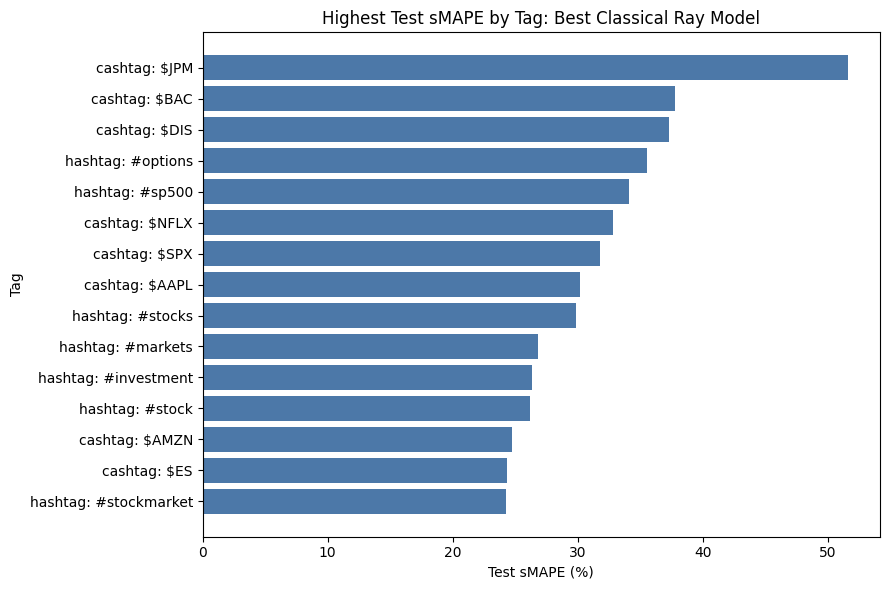

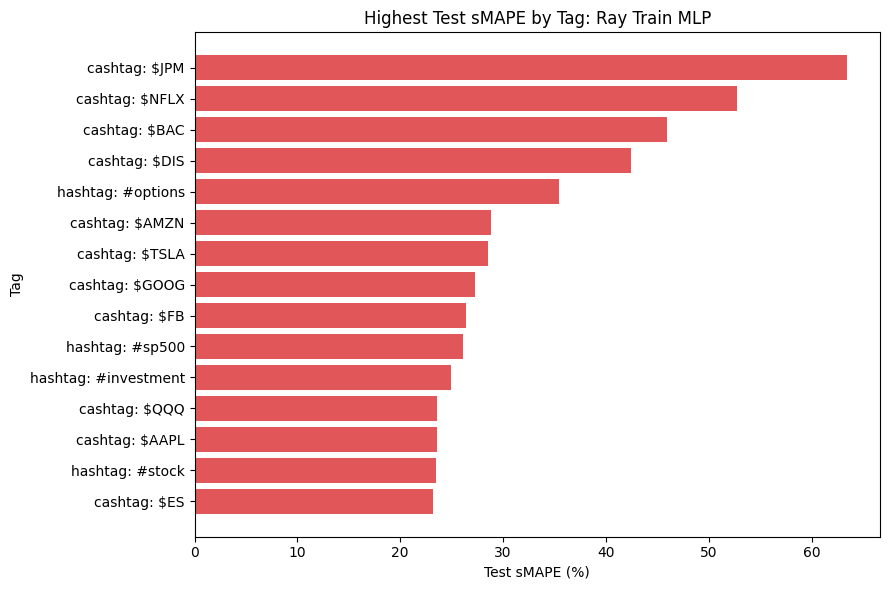

In [15]:
def plot_by_tag_errors(frame, title, color):
    if frame is None or frame.empty:
        note(f"Skipping {title}; no by-tag metrics available.")
        return
    plot_frame = frame.sort_values("sMAPE", ascending=False).head(15).sort_values("sMAPE")
    labels = plot_frame["tag_type"] + ": " + plot_frame["tag"]
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(labels, plot_frame["sMAPE"], color=color)
    ax.set_title(title)
    ax.set_xlabel("Test sMAPE (%)")
    ax.set_ylabel("Tag")
    plt.tight_layout()
    plt.show()

plot_by_tag_errors(ray_by_tag, "Highest Test sMAPE by Tag: Best Classical Ray Model", "#4C78A8")
plot_by_tag_errors(mlp_by_tag, "Highest Test sMAPE by Tag: Ray Train MLP", "#E15759")


,tag_type,tag,classical_sMAPE,mlp_sMAPE,mlp_minus_classical
2,cashtag,$SPX,31.770419,20.261181,-11.509238
21,hashtag,#sp500,34.093084,26.147522,-7.945561
0,hashtag,#stocks,29.822945,22.099894,-7.723051
5,hashtag,#stockmarket,24.216954,16.928749,-7.288205
1,cashtag,$AAPL,30.179991,23.525151,-6.654840
22,hashtag,#markets,26.810737,21.739501,-5.071236
27,hashtag,#daytrading,21.156154,16.879158,-4.276995
10,hashtag,#investing,20.216177,16.053315,-4.162862
12,hashtag,#stock,26.167581,23.429874,-2.737706
11,hashtag,#investment,26.314380,24.905740,-1.408640


,tag_type,tag,classical_sMAPE,mlp_sMAPE,mlp_minus_classical
13,cashtag,$NFLX,32.798772,52.750937,19.952165
19,cashtag,$GOOG,13.907411,27.263849,13.356438
4,cashtag,$JPM,51.575185,63.467532,11.892347
17,cashtag,$BAC,37.794219,45.964175,8.169956
9,cashtag,$FB,19.530051,26.411559,6.881508
7,cashtag,$TSLA,21.747106,28.547762,6.800655
16,cashtag,$MSFT,12.718082,18.170171,5.452089
8,cashtag,$DIS,37.257074,42.451136,5.194062
3,cashtag,$AMZN,24.703731,28.849802,4.146071
15,hashtag,#trading,16.821696,18.949001,2.127306


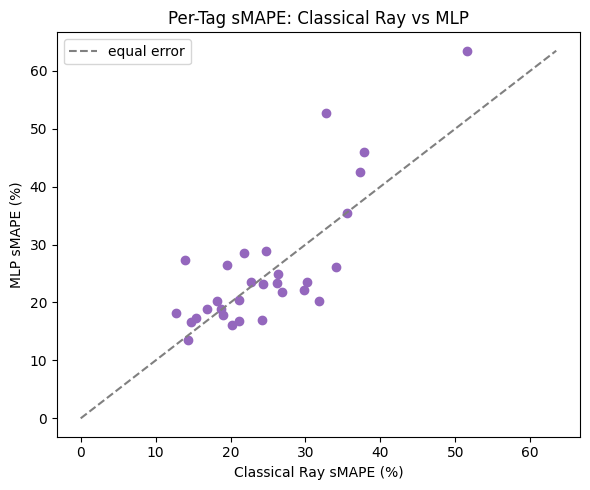

In [16]:
if ray_by_tag is not None and mlp_by_tag is not None:
    ray_small = ray_by_tag[["tag_type", "tag", "sMAPE"]].rename(columns={"sMAPE": "classical_sMAPE"})
    mlp_small = mlp_by_tag[["tag_type", "tag", "sMAPE"]].rename(columns={"sMAPE": "mlp_sMAPE"})
    tag_compare = ray_small.merge(mlp_small, on=["tag_type", "tag"], how="inner")
    tag_compare["mlp_minus_classical"] = tag_compare["mlp_sMAPE"] - tag_compare["classical_sMAPE"]
    display(tag_compare.sort_values("mlp_minus_classical").head(10))
    display(tag_compare.sort_values("mlp_minus_classical", ascending=False).head(10))

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(tag_compare["classical_sMAPE"], tag_compare["mlp_sMAPE"], color="#9467BD")
    limit = max(tag_compare["classical_sMAPE"].max(), tag_compare["mlp_sMAPE"].max())
    ax.plot([0, limit], [0, limit], linestyle="--", color="gray", label="equal error")
    ax.set_title("Per-Tag sMAPE: Classical Ray vs MLP")
    ax.set_xlabel("Classical Ray sMAPE (%)")
    ax.set_ylabel("MLP sMAPE (%)")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    note("Skipping per-tag MLP vs classical comparison because one by-tag file is missing.")


## 7. Hashtag vs Cashtag Performance

These grouped metrics show whether the models behave differently on hashtags and cashtags.


In [17]:
ray_by_type = read_csv_if_exists("ray_model_metrics_by_tag_type_count_only.csv")
mlp_by_type = read_csv_if_exists("ray_train_mlp_metrics_by_tag_type_mlp_count_only.csv")

if ray_by_type is not None:
    display(ray_by_type)
else:
    note("Classical Ray by-tag-type metrics are missing.")

if mlp_by_type is not None:
    display(mlp_by_type)
else:
    note("MLP by-tag-type metrics are missing.")


,split,tag_type,model,rows,MAE,RMSE,sMAPE
0,test,cashtag,random_forest_pooled,150,123.843239,185.346606,26.577509
1,test,cashtag,hist_gradient_boosting_pooled,150,125.123791,186.493726,27.185488
2,test,cashtag,ridge_regression_pooled,150,136.815226,204.881706,29.661837
3,test,cashtag,linear_regression_pooled,150,137.590119,210.943080,31.014120
4,test,cashtag,baseline_last_value,150,157.893333,259.750111,32.456933
5,test,hashtag,random_forest_pooled,150,89.523151,195.380320,22.982566
6,test,hashtag,hist_gradient_boosting_pooled,150,89.459415,174.781190,24.132355
7,test,hashtag,ridge_regression_pooled,150,97.512111,210.931654,25.234538
8,test,hashtag,linear_regression_pooled,150,103.980619,205.282437,27.430643
9,test,hashtag,baseline_last_value,150,106.506667,260.409549,28.409540


,split,tag_type,model,rows,MAE,RMSE,sMAPE
0,test,cashtag,ray_train_mlp,150,131.387062,193.042413,30.741623
1,test,hashtag,ray_train_mlp,150,77.497735,170.620280,20.725626
2,validation,cashtag,ray_train_mlp,165,150.228278,259.067760,41.399408
3,validation,hashtag,ray_train_mlp,165,76.647735,144.429319,31.640889


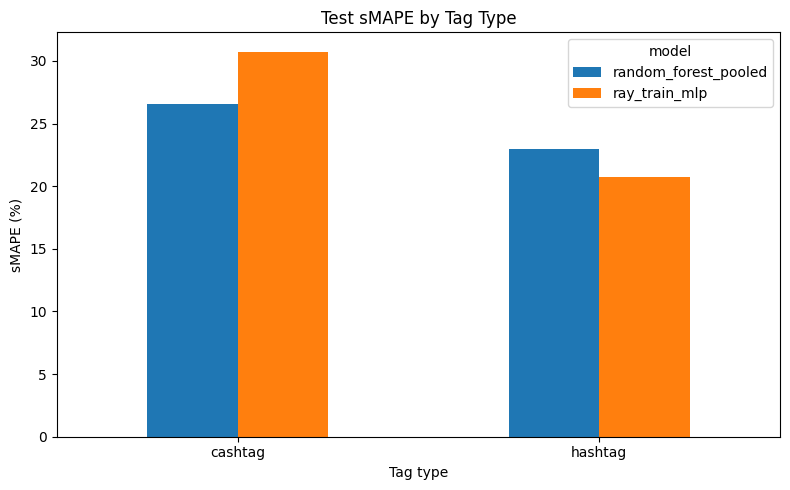

In [18]:
by_type_frames = []
if ray_by_type is not None:
    temp = ray_by_type.copy()
    if best_classical is not None:
        temp = temp[temp["model"].eq(best_classical["model"].iloc[0])]
    by_type_frames.append(temp)
if mlp_by_type is not None:
    by_type_frames.append(mlp_by_type.copy())

if by_type_frames:
    by_type_all = pd.concat(by_type_frames, ignore_index=True)
    test_by_type = by_type_all[by_type_all["split"].eq("test")].copy()
    if not test_by_type.empty:
        pivot = test_by_type.pivot_table(index="tag_type", columns="model", values="sMAPE", aggfunc="first")
        ax = pivot.plot(kind="bar", figsize=(8, 5))
        ax.set_title("Test sMAPE by Tag Type")
        ax.set_xlabel("Tag type")
        ax.set_ylabel("sMAPE (%)")
        ax.tick_params(axis="x", rotation=0)
        plt.tight_layout()
        plt.show()
else:
    note("Skipping tag-type chart because by-tag-type metrics are unavailable.")


## 8. Training-Time and Runtime Analysis

Training time is part of the systems story: classical Ray parallelizes sklearn models, while Ray Train trains the PyTorch MLP and can use a GPU when `--use-gpu` is passed.


In [19]:
ray_times = read_csv_if_exists("ray_model_training_times_count_only.csv")
mlp_time = read_csv_if_exists("ray_train_mlp_training_time_mlp_count_only.csv")
mlp_summary = read_json_if_exists("ray_train_mlp_run_summary_mlp_count_only.json")

if ray_times is not None:
    display(ray_times)
else:
    note("Classical Ray training-time CSV is missing.")

if mlp_time is not None:
    display(mlp_time)
else:
    note("MLP compact training-time CSV is missing.")

if mlp_summary is not None:
    print("MLP summary device:", mlp_summary.get("device_used"), "GPU requested:", mlp_summary.get("gpu_requested"))
else:
    note("MLP run summary JSON is missing.")


,run_label,model,train_seconds,feature_set,rows_train,num_numeric_features
0,count_only,linear_regression_pooled,0.013767,count_only,1440,11
1,count_only,ridge_regression_pooled,0.012435,count_only,1440,11
2,count_only,random_forest_pooled,0.673204,count_only,1440,11
3,count_only,hist_gradient_boosting_pooled,0.196715,count_only,1440,11


,run_label,model,feature_set,train_seconds,epochs,batch_size,num_workers,use_gpu,device_used
0,mlp_count_only,ray_train_mlp,count_only,197.934614,100,64,1,True,cuda


MLP summary device: cuda GPU requested: True


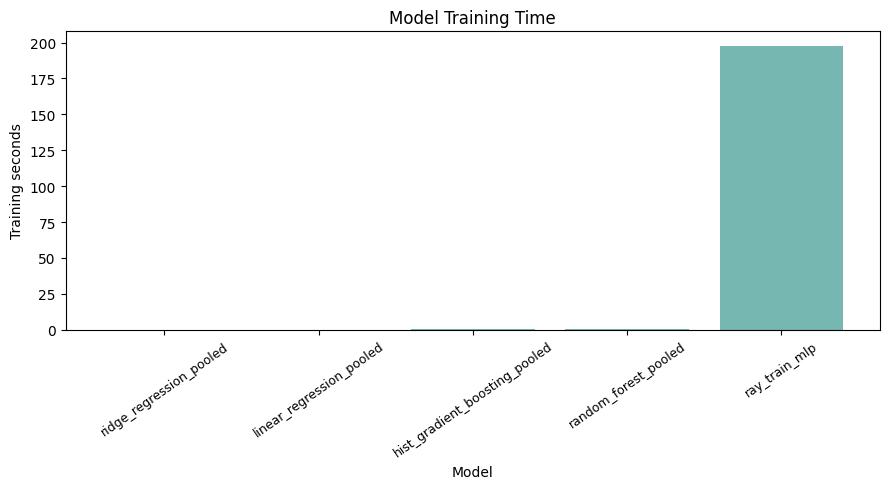

In [20]:
time_rows = []
if ray_times is not None:
    for _, row in ray_times.iterrows():
        time_rows.append({"model": row["model"], "train_seconds": row["train_seconds"], "source": "classical_ray"})
if mlp_time is not None and not mlp_time.empty:
    row = mlp_time.iloc[0]
    time_rows.append({"model": row["model"], "train_seconds": row["train_seconds"], "source": "ray_train_mlp"})

runtime = pd.DataFrame(time_rows)
if not runtime.empty:
    runtime_plot = runtime.sort_values("train_seconds")
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(runtime_plot["model"], runtime_plot["train_seconds"], color="#76B7B2")
    ax.set_title("Model Training Time")
    ax.set_xlabel("Model")
    ax.set_ylabel("Training seconds")
    ax.tick_params(axis="x", rotation=35, labelsize=9)
    plt.tight_layout()
    plt.show()
else:
    note("Skipping training-time bar chart because timing files are unavailable.")


,model,sMAPE,train_seconds,source
2,random_forest_pooled,24.780038,0.673204,classical_ray
3,hist_gradient_boosting_pooled,25.658922,0.196715,classical_ray
4,ray_train_mlp,25.733625,197.934614,ray_train_mlp
1,ridge_regression_pooled,27.448188,0.012435,classical_ray
0,linear_regression_pooled,29.222381,0.013767,classical_ray


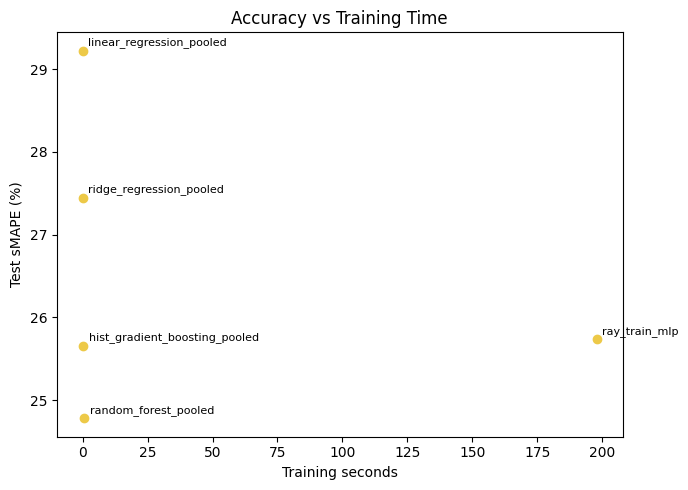

In [21]:
if not all_metrics.empty and not runtime.empty:
    test_smape = all_metrics[all_metrics["split"].eq("test")][["model", "sMAPE"]].copy()
    speed_accuracy = test_smape.merge(runtime, on="model", how="inner")
    if not speed_accuracy.empty:
        display(speed_accuracy.sort_values("sMAPE"))
        fig, ax = plt.subplots(figsize=(7, 5))
        ax.scatter(speed_accuracy["train_seconds"], speed_accuracy["sMAPE"], color="#EDC948")
        for _, row in speed_accuracy.iterrows():
            ax.annotate(row["model"], (row["train_seconds"], row["sMAPE"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
        ax.set_title("Accuracy vs Training Time")
        ax.set_xlabel("Training seconds")
        ax.set_ylabel("Test sMAPE (%)")
        plt.tight_layout()
        plt.show()
    else:
        note("No overlapping model names between timing and test metric files.")
else:
    note("Skipping accuracy-vs-time plot because metrics or timing files are unavailable.")


## 9. MLP Learning Curve

The Ray Train MLP training history stores epoch-level train loss, validation metrics, and elapsed time.


,epoch,train_loss,validation_MAE,validation_RMSE,validation_sMAPE,elapsed_seconds
0,1,0.210826,160.819607,253.865052,50.336331,0.236507
1,2,0.100582,148.558094,269.276006,43.324892,0.288267
2,3,0.086947,137.592023,241.230328,42.019955,1.060735
3,4,0.083644,134.721761,235.275911,41.347183,3.064288
4,5,0.086591,133.925148,234.464764,41.152871,5.075106


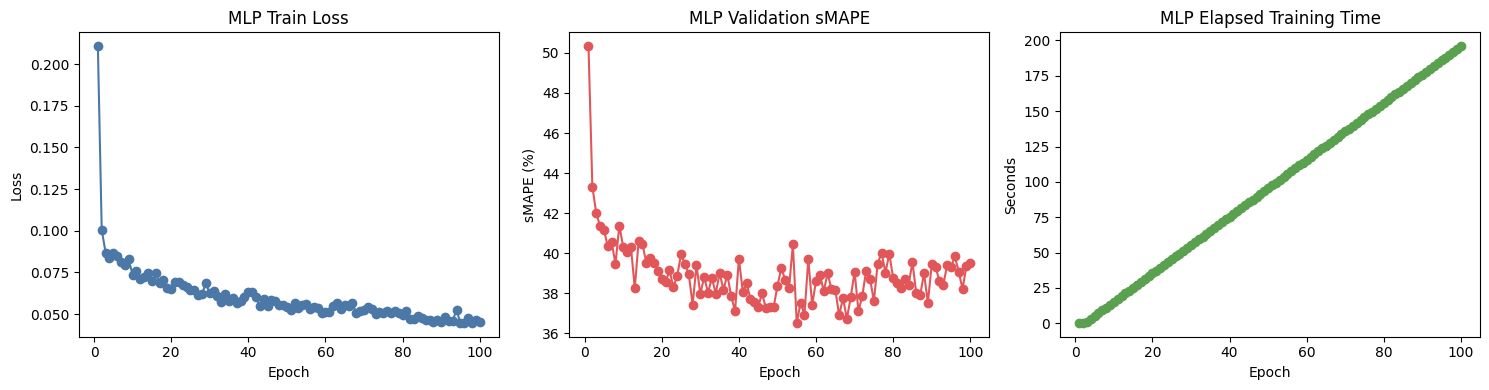

In [22]:
mlp_history = read_csv_if_exists("ray_train_mlp_training_history_mlp_count_only.csv")

if mlp_history is not None:
    display(mlp_history.head())
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(mlp_history["epoch"], mlp_history["train_loss"], marker="o", color="#4C78A8")
    axes[0].set_title("MLP Train Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")

    axes[1].plot(mlp_history["epoch"], mlp_history["validation_sMAPE"], marker="o", color="#E15759")
    axes[1].set_title("MLP Validation sMAPE")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("sMAPE (%)")

    if "elapsed_seconds" in mlp_history.columns:
        axes[2].plot(mlp_history["epoch"], mlp_history["elapsed_seconds"], marker="o", color="#59A14F")
        axes[2].set_title("MLP Elapsed Training Time")
        axes[2].set_xlabel("Epoch")
        axes[2].set_ylabel("Seconds")
    else:
        axes[2].axis("off")
        axes[2].text(0.05, 0.5, "elapsed_seconds not available", fontsize=11)

    plt.tight_layout()
    plt.show()
else:
    note("MLP training history is missing, so learning curves are skipped.")


## MLP Deep-Dive Visualizations

The overall metrics show how the Ray Train MLP performed in aggregate, but they do not explain where the neural model succeeds or fails. This section uses the saved MLP prediction artifact to inspect calibration, residuals, tag/date error patterns, count-scale effects, and the largest individual misses.


In [23]:
mlp_prediction_candidates = [
    "ray_train_mlp_predictions_mlp_count_only.parquet",
    "ray_train_mlp_predictions_mlp_smoke.parquet",
]

mlp_prediction_path = None
for filename in mlp_prediction_candidates:
    candidate = derived_dir / filename
    if candidate.exists():
        mlp_prediction_path = candidate
        break

mlp_eval = pd.DataFrame()
if mlp_prediction_path is None:
    note("No MLP prediction parquet was found, so MLP deep-dive plots are skipped.")
else:
    raw_mlp = pd.read_parquet(mlp_prediction_path)
    mlp_eval = raw_mlp.copy()

    rename_candidates = {
        "target_next_count": "actual",
        "actual": "actual",
        "y_true": "actual",
        "prediction": "prediction",
        "y_pred": "prediction",
        "predicted": "prediction",
    }
    for old_name, new_name in rename_candidates.items():
        if old_name in mlp_eval.columns and new_name not in mlp_eval.columns:
            mlp_eval = mlp_eval.rename(columns={old_name: new_name})

    needed = {"actual", "prediction"}
    if not needed.issubset(mlp_eval.columns):
        note(f"MLP predictions are missing required columns: {sorted(needed - set(mlp_eval.columns))}")
        mlp_eval = pd.DataFrame()
    else:
        if "date" in mlp_eval.columns:
            mlp_eval["date"] = pd.to_datetime(mlp_eval["date"])
        else:
            mlp_eval["date"] = pd.NaT
        if "tag" not in mlp_eval.columns:
            mlp_eval["tag"] = "unknown_tag"
        if "tag_type" not in mlp_eval.columns:
            mlp_eval["tag_type"] = "unknown"
        if "split" not in mlp_eval.columns:
            mlp_eval["split"] = "unknown"

        mlp_eval["actual"] = pd.to_numeric(mlp_eval["actual"], errors="coerce")
        mlp_eval["prediction"] = pd.to_numeric(mlp_eval["prediction"], errors="coerce")
        mlp_eval = mlp_eval.dropna(subset=["actual", "prediction"]).copy()
        mlp_eval["residual"] = mlp_eval["prediction"] - mlp_eval["actual"]
        mlp_eval["abs_error"] = mlp_eval["residual"].abs()
        denominator = mlp_eval["actual"].abs() + mlp_eval["prediction"].abs()
        mlp_eval["row_sMAPE"] = np.where(denominator == 0, 0.0, 200 * mlp_eval["abs_error"] / denominator)

        print("Using MLP prediction artifact:", mlp_prediction_path)
        print("MLP evaluation rows:", len(mlp_eval))
        display(mlp_eval.head())


Using MLP prediction artifact: C:\Users\nolan\OneDrive\Desktop\Code\CS8540 Project\CS8540-Project\phase2\data\derived\ray_train_mlp_predictions_mlp_count_only.parquet
MLP evaluation rows: 630


,date,tag,tag_type,split,actual,model,prediction,residual,abs_error,row_sMAPE
0,2020-06-25,$AAPL,cashtag,validation,1029.0,ray_train_mlp,1109.769897,80.769897,80.769897,7.552930
1,2020-06-26,$AAPL,cashtag,validation,522.0,ray_train_mlp,695.909302,173.909302,173.909302,28.558662
2,2020-06-27,$AAPL,cashtag,validation,473.0,ray_train_mlp,443.393616,-29.606384,29.606384,6.461499
3,2020-06-28,$AAPL,cashtag,validation,958.0,ray_train_mlp,720.759155,-237.240845,237.240845,28.263833
4,2020-06-29,$AAPL,cashtag,validation,1191.0,ray_train_mlp,807.387268,-383.612732,383.612732,38.392231


### 1. MLP Actual vs Predicted Scatterplot

This scatterplot checks calibration. Points near the diagonal are accurate; points above the line are overpredictions, and points below the line are underpredictions.


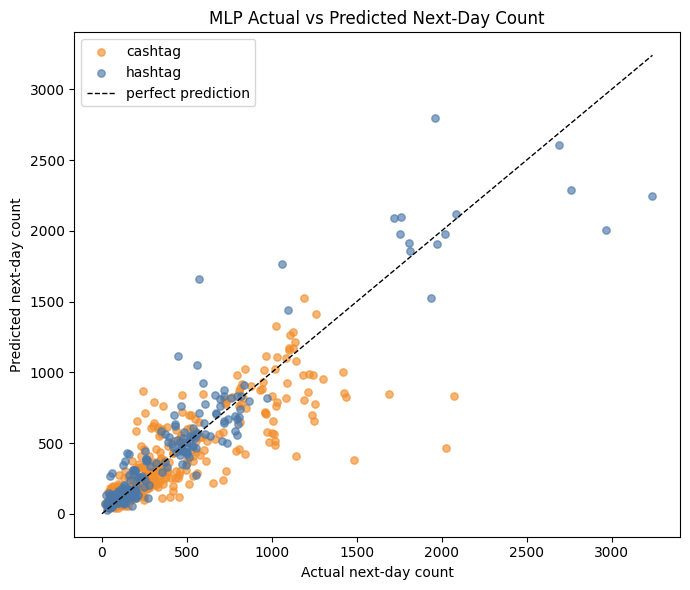

In [24]:
if mlp_eval.empty:
    note("Skipping MLP actual-vs-predicted scatterplot because MLP predictions are unavailable.")
else:
    fig, ax = plt.subplots(figsize=(7, 6))
    color_map = {"hashtag": "#4C78A8", "cashtag": "#F28E2B", "unknown": "#999999"}
    for tag_type, group in mlp_eval.groupby("tag_type"):
        ax.scatter(
            group["actual"],
            group["prediction"],
            alpha=0.65,
            s=28,
            label=tag_type,
            color=color_map.get(tag_type, "#999999"),
        )
    limit = max(mlp_eval["actual"].max(), mlp_eval["prediction"].max())
    ax.plot([0, limit], [0, limit], linestyle="--", color="black", linewidth=1, label="perfect prediction")
    ax.set_title("MLP Actual vs Predicted Next-Day Count")
    ax.set_xlabel("Actual next-day count")
    ax.set_ylabel("Predicted next-day count")
    ax.legend()
    plt.tight_layout()
    plt.show()


### 2. MLP Error Heatmap by Tag and Date

The heatmap shows row-level sMAPE by tag and date for the highest-volume tags. It helps identify whether errors cluster around specific tags or time periods.


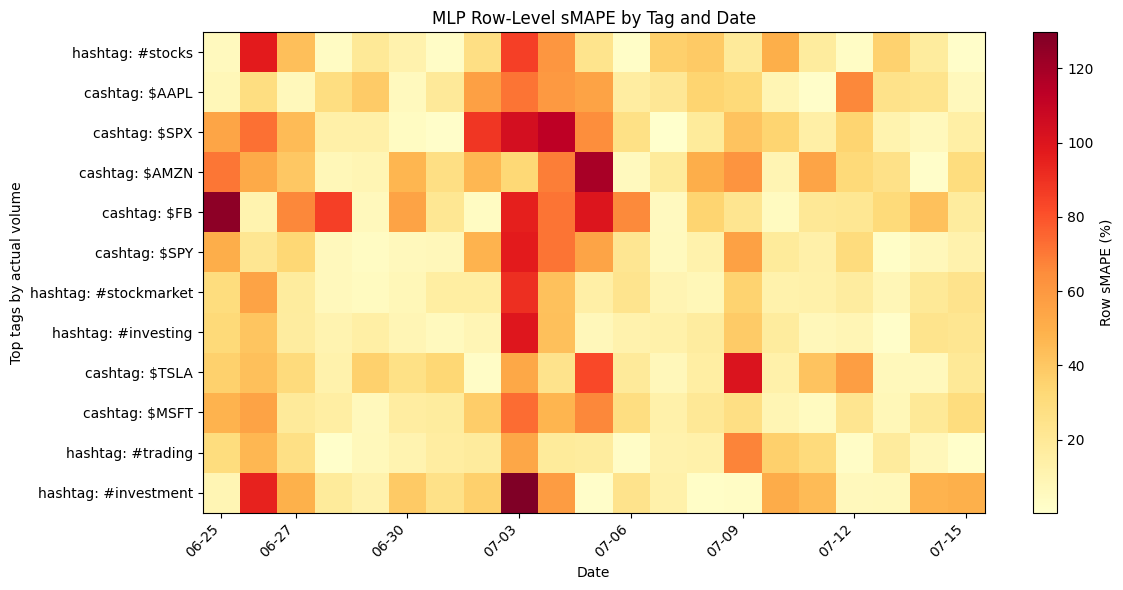

In [25]:
if mlp_eval.empty or mlp_eval["date"].isna().all():
    note("Skipping MLP tag/date heatmap because date-level MLP predictions are unavailable.")
else:
    top_tags = (
        mlp_eval.groupby(["tag_type", "tag"], as_index=False)["actual"]
        .sum()
        .sort_values("actual", ascending=False)
        .head(12)
    )
    heat_source = mlp_eval.merge(top_tags[["tag_type", "tag"]], on=["tag_type", "tag"], how="inner").copy()
    heat_source["tag_label"] = heat_source["tag_type"] + ": " + heat_source["tag"]
    heat = heat_source.pivot_table(index="tag_label", columns="date", values="row_sMAPE", aggfunc="mean")
    heat = heat.reindex(top_tags["tag_type"] + ": " + top_tags["tag"])

    fig, ax = plt.subplots(figsize=(12, 6))
    image = ax.imshow(heat.values, aspect="auto", cmap="YlOrRd")
    ax.set_title("MLP Row-Level sMAPE by Tag and Date")
    ax.set_xlabel("Date")
    ax.set_ylabel("Top tags by actual volume")
    ax.set_yticks(np.arange(len(heat.index)))
    ax.set_yticklabels(heat.index)

    tick_count = min(8, len(heat.columns))
    tick_positions = np.linspace(0, len(heat.columns) - 1, tick_count, dtype=int)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels([heat.columns[pos].strftime("%m-%d") for pos in tick_positions], rotation=45, ha="right")
    cbar = fig.colorbar(image, ax=ax)
    cbar.set_label("Row sMAPE (%)")
    plt.tight_layout()
    plt.show()


### 3. MLP Error by Actual Count Bucket

This boxplot groups examples by actual next-day count quantiles. It shows whether the MLP struggles more on low-count, medium-count, or high-count cases.


C:\Users\nolan\AppData\Local\Temp\ipykernel_54540\3029046241.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(bucket_values, labels=bucket_labels, showfliers=False)


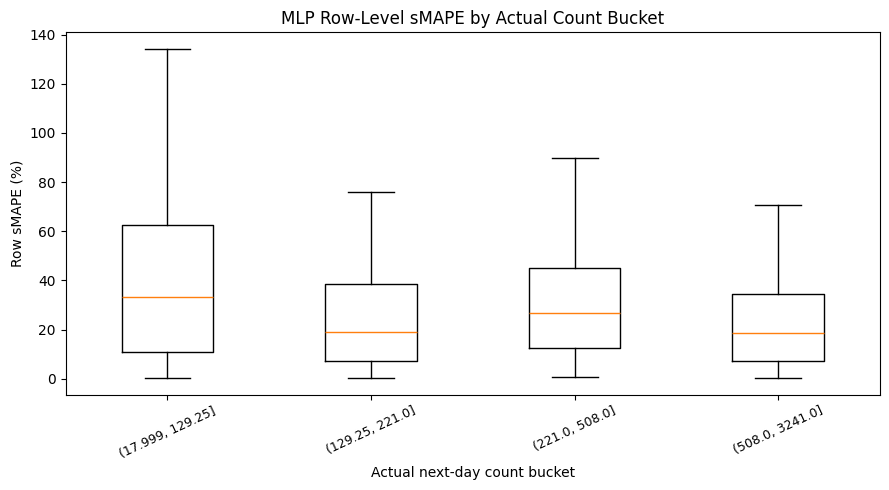

actual                    row_sMAPE                       abs_error                        
                  count        mean median     count       mean     median     count        mean      median
actual_bucket                                                                                               
(17.999, 129.25]    158   81.012658   83.5       158  41.188049  33.488783       158   39.790192   25.761559
(129.25, 221.0]     157  170.522293  170.0       157  26.293108  19.036543       157   49.706186   33.286774
(221.0, 508.0]      157  347.821656  337.0       157  31.772470  26.861212       157  116.190149   82.498840
(508.0, 3241.0]     158  964.417722  811.0       158  26.251449  18.562394       158  230.599282  149.618683

In [26]:
if mlp_eval.empty:
    note("Skipping MLP error-by-bucket plot because MLP predictions are unavailable.")
else:
    bucket_frame = mlp_eval.copy()
    try:
        bucket_frame["actual_bucket"] = pd.qcut(bucket_frame["actual"], q=4, duplicates="drop")
    except ValueError:
        bucket_frame["actual_bucket"] = pd.cut(bucket_frame["actual"], bins=4)

    bucket_frame = bucket_frame.dropna(subset=["actual_bucket"])
    bucket_labels = [str(bucket) for bucket in bucket_frame["actual_bucket"].cat.categories]
    bucket_values = [bucket_frame.loc[bucket_frame["actual_bucket"].eq(bucket), "row_sMAPE"] for bucket in bucket_frame["actual_bucket"].cat.categories]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.boxplot(bucket_values, labels=bucket_labels, showfliers=False)
    ax.set_title("MLP Row-Level sMAPE by Actual Count Bucket")
    ax.set_xlabel("Actual next-day count bucket")
    ax.set_ylabel("Row sMAPE (%)")
    ax.tick_params(axis="x", rotation=25, labelsize=9)
    plt.tight_layout()
    plt.show()

    display(bucket_frame.groupby("actual_bucket", observed=True)[["actual", "row_sMAPE", "abs_error"]].agg(["count", "mean", "median"]))


### 4. MLP Residual Distribution

Residuals are calculated as `prediction - actual`. Values above zero are overpredictions; values below zero are underpredictions.


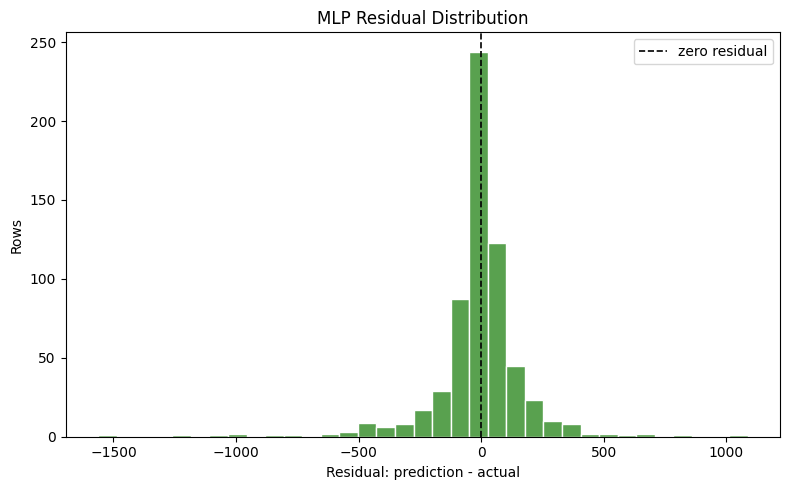

Mean residual: -11.71
Median residual: -0.69


In [27]:
if mlp_eval.empty:
    note("Skipping MLP residual histogram because MLP predictions are unavailable.")
else:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(mlp_eval["residual"], bins=35, color="#59A14F", edgecolor="white")
    ax.axvline(0, color="black", linestyle="--", linewidth=1.2, label="zero residual")
    ax.set_title("MLP Residual Distribution")
    ax.set_xlabel("Residual: prediction - actual")
    ax.set_ylabel("Rows")
    ax.legend()
    plt.tight_layout()
    plt.show()

    print("Mean residual:", round(mlp_eval["residual"].mean(), 2))
    print("Median residual:", round(mlp_eval["residual"].median(), 2))


### 5. MLP Top Overpredictions and Underpredictions

The largest positive and negative residuals are useful presentation examples because they show concrete tags and dates where the MLP missed badly.


Largest MLP overpredictions


,date,tag_type,tag,actual,prediction,residual,abs_error,row_sMAPE
309,2020-06-26,hashtag,#stocks,573.0,1659.032471,1086.032471,1086.032471,97.313322
617,2020-07-13,hashtag,#stocks,1959.0,2800.137695,841.137695,841.137695,35.348324
614,2020-07-10,hashtag,#stocks,1059.0,1763.336304,704.336304,704.336304,49.911579
316,2020-07-03,hashtag,#stocks,447.0,1115.626221,668.626221,668.626221,85.577243
141,2020-07-04,cashtag,$SPX,241.0,867.017029,626.017029,626.017029,112.997727
317,2020-07-04,hashtag,#stocks,562.0,1049.017456,487.017456,487.017456,60.460854
139,2020-07-02,cashtag,$SPX,306.0,791.682190,485.682190,485.682190,88.492315
63,2020-07-03,cashtag,$FB,251.0,712.732239,461.732239,461.732239,95.821686


Largest MLP underpredictions


,date,tag_type,tag,actual,prediction,residual,abs_error,row_sMAPE
55,2020-06-25,cashtag,$FB,2024.0,461.557495,-1562.442505,1562.442505,125.721695
58,2020-06-28,cashtag,$FB,2075.0,833.132019,-1241.867981,1241.867981,85.406575
21,2020-07-05,cashtag,$AMZN,1482.0,377.349976,-1104.650024,1104.650024,118.821098
611,2020-07-07,hashtag,#stocks,3241.0,2245.380127,-995.619873,995.619873,36.294236
612,2020-07-08,hashtag,#stocks,2965.0,2002.939819,-962.060181,962.060181,38.730750
336,2020-07-12,cashtag,$AAPL,1690.0,847.783813,-842.216187,842.216187,66.374148
417,2020-07-13,cashtag,$JPM,1142.0,407.230988,-734.769012,734.769012,94.855966
132,2020-06-25,cashtag,$SPX,1434.0,822.689392,-611.310608,611.310608,54.177647


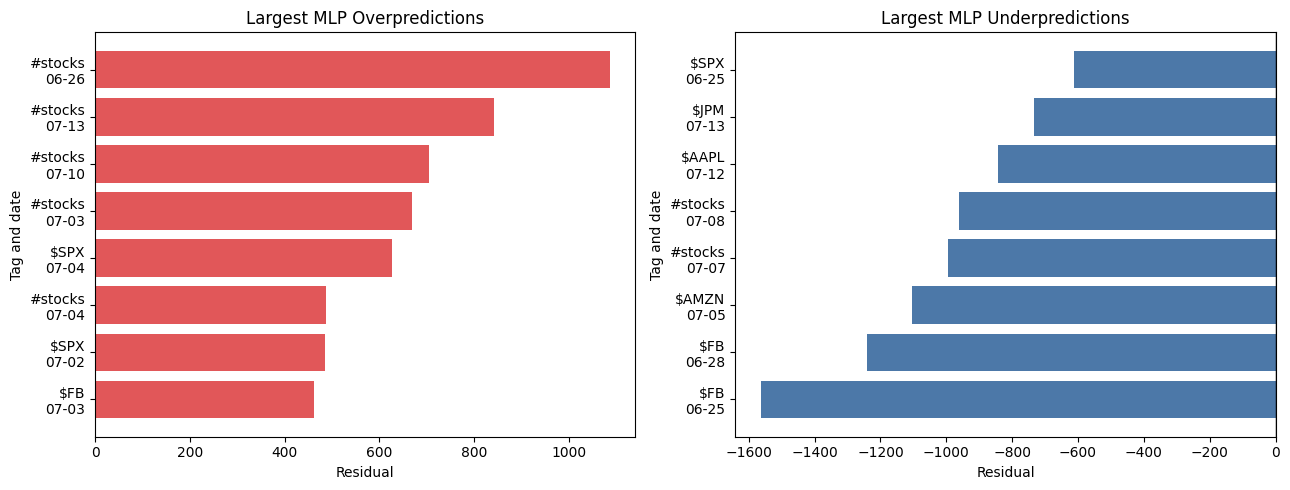

In [28]:
if mlp_eval.empty:
    note("Skipping top MLP miss cases because MLP predictions are unavailable.")
else:
    detail_cols = ["date", "tag_type", "tag", "actual", "prediction", "residual", "abs_error", "row_sMAPE"]
    over = mlp_eval.sort_values("residual", ascending=False).head(8).copy()
    under = mlp_eval.sort_values("residual", ascending=True).head(8).copy()

    print("Largest MLP overpredictions")
    display(over[detail_cols])
    print("Largest MLP underpredictions")
    display(under[detail_cols])

    over_labels = over["tag"] + "\n" + over["date"].dt.strftime("%m-%d")
    under_labels = under["tag"] + "\n" + under["date"].dt.strftime("%m-%d")

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
    axes[0].barh(over_labels[::-1], over["residual"][::-1], color="#E15759")
    axes[0].set_title("Largest MLP Overpredictions")
    axes[0].set_xlabel("Residual")
    axes[0].set_ylabel("Tag and date")

    axes[1].barh(under_labels, under["residual"], color="#4C78A8")
    axes[1].set_title("Largest MLP Underpredictions")
    axes[1].set_xlabel("Residual")
    axes[1].set_ylabel("Tag and date")
    axes[1].axvline(0, color="black", linewidth=1)

    plt.tight_layout()
    plt.show()


These diagnostics make the MLP easier to explain than a single aggregate metric. Together they show calibration, time-and-tag error clusters, whether count scale matters, the direction of residual bias, and the most important failure cases to discuss in the final presentation.


## 10. Systems and Run Summary

The JSON summaries and timing files capture the run settings needed for the Big Data systems discussion.


In [29]:
ray_summary = read_json_if_exists("ray_model_run_summary_count_only.json")
mlp_summary = read_json_if_exists("ray_train_mlp_run_summary_mlp_count_only.json")
summary_rows = []

if ray_summary is not None:
    summary_rows.append({
        "run": "classical_ray_count_only",
        "feature_file": ray_summary.get("features"),
        "gpu_requested": False,
        "device_used": "cpu/sklearn",
        "epochs": np.nan,
        "batch_size": np.nan,
        "num_workers": ray_summary.get("num_workers"),
        "total_training_seconds": sum(ray_summary.get("model_training_seconds", {}).values()) if ray_summary.get("model_training_seconds") else np.nan,
    })

if mlp_summary is not None:
    params = mlp_summary.get("model_params", {})
    summary_rows.append({
        "run": mlp_summary.get("run_label", "mlp_count_only"),
        "feature_file": mlp_summary.get("features"),
        "gpu_requested": mlp_summary.get("gpu_requested"),
        "device_used": mlp_summary.get("device_used"),
        "epochs": params.get("epochs"),
        "batch_size": params.get("batch_size"),
        "num_workers": mlp_summary.get("rows", {}).get("workers", 1),
        "total_training_seconds": mlp_summary.get("total_training_seconds"),
    })

systems_summary = pd.DataFrame(summary_rows)
if not systems_summary.empty:
    display(systems_summary)
else:
    note("No run summary JSON files are available.")


,run,feature_file,gpu_requested,device_used,epochs,batch_size,num_workers,total_training_seconds
0,classical_ray_count_only,phase2/data/derived/top_tags_daily_features.pa...,False,cpu/sklearn,NaN,NaN,NaN,0.896120
1,mlp_count_only,phase2/data/derived/top_tags_daily_features.pa...,True,cuda,100.0,64.0,1.0,197.934614


## 11. Optional Sentiment Section

Sentiment is secondary in the final project story. This section appears only if sentiment-derived artifacts are available.


In [30]:
sentiment_table = read_parquet_if_exists("top_tags_daily_features_with_sentiment.parquet")
sentiment_comparison = read_csv_if_exists("sentiment_forecast_comparison.csv")

if sentiment_table is None and sentiment_comparison is None:
    note("No sentiment-derived feature table or comparison CSV is available. Skipping sentiment visuals.")
else:
    if sentiment_table is not None:
        print("Sentiment feature table shape:", sentiment_table.shape)
        sentiment_cols = [col for col in sentiment_table.columns if "sentiment" in col or "positive" in col or "negative" in col]
        display(sentiment_table[sentiment_cols].describe().T.head(12))
        if "sentiment_tweet_count" in sentiment_table.columns:
            coverage = (sentiment_table["sentiment_tweet_count"] > 0).mean()
            print(f"Rows with sentiment coverage: {coverage:.1%}")
    if sentiment_comparison is not None:
        print("Sentiment comparison artifact:")
        display(sentiment_comparison)


Sentiment comparison artifact:


,run_label,split,model,rows,MAE,RMSE,sMAPE
0,count_only,test,random_forest_pooled,300,106.683195,190.429559,24.780038
1,count_only,test,hist_gradient_boosting_pooled,300,107.291603,180.732363,25.658922
2,count_only,test,ridge_regression_pooled,300,117.163668,207.928685,27.448188
3,count_only,test,linear_regression_pooled,300,120.785369,208.132004,29.222381
4,count_only,test,baseline_last_value,300,132.200000,260.080039,30.433236
5,count_only,validation,random_forest_pooled,330,124.687109,228.405360,38.027573
6,count_only,validation,hist_gradient_boosting_pooled,330,124.135463,230.334801,38.276467
7,count_only,validation,linear_regression_pooled,330,126.369841,227.895865,40.020035
8,count_only,validation,ridge_regression_pooled,330,130.620161,226.089798,41.445293
9,count_only,validation,baseline_last_value,330,147.648485,278.857681,44.964269


## 12. Final Takeaway

Use the cells above to report:

- which model had the best validation and test sMAPE
- how the Ray Train MLP compared with the best classical Ray model
- how long the classical Ray models and MLP took to train
- whether the MLP's extra training cost was worthwhile for the observed accuracy
- that Ray was used for classical model parallelism and Ray Train was used for PyTorch neural-network training

Main limitation: the MLP trains on derived daily count features, not raw tweet text. It predicts next-day tag count from historical tag-count patterns and tag identity.
